# Практическая работа 1 - Scikit-Learn для задач МО
> Практическая работа предполагает выполнение набора упражнений для различных задач с использованием Scikit-Learn. Оценка за работу - 10.

Примечания:
* Может существовать более одного способа ответить на вопрос или выполнить упражнение.
* Для вас уже реализован некоторый каркасный код.
* Упражнения основаны (и напрямую взяты) из краткого [вводного пособия по Scikit-Learn](https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn.ipynb).
* Различные задачи будут описаны в комментариях или тексте. Места для вашего кода обозначены `###` (не удаляйте ничего, кроме `###`).


Для дальнейших ссылок и ресурсов рекомендуется ознакомиться с [документацией Scikit-Learn](https://scikit-learn.org/stable/user_guide.html).

Поскольку мы будем работать с данными, мы импортируем соответствующие компоненты Scikit-Learn: Matplotlib, NumPy и pandas.

In [ ]:
# Setup matplotlib to plot inline (within the notebook)
%matplotlib inline

# Import the pyplot module of Matplotlib as plt
import matplotlib.pyplot as plt

# Import pandas under the abbreviation 'pd'
import pandas as pd

# Import NumPy under the abbreviation 'np'
import numpy as np

## Сквозная задача классификации в Scikit-Learn

Порядок выполнения задачи:
1. Подготовить набор данных
2. Подготовить модель машинного обучения для прогнозирования
3. Доработка модели к данным для  прогноза
4. Оценить прогнозы модели

Данные, которые будем использовать, [хранятся на GitHub](https://github.com/mrdbourke/zero-to-mastery-ml/tree/master/data). Мы начнем с [`heart-disease.csv`](https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv), набора данных, который содержит анонимные данные пациентов и наличие или отсутствие у них сердечных заболеваний.
Также файл heart-disease.csv можно загрузить.

**Примечание:** При просмотре файла `.csv` на GitHub убедитесь, что он находится в сыром формате. Например, URL должен выглядеть так: https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv

### 1. Подготовка набора данных

In [ ]:
!pip install ucimlrepo

In [ ]:
# Import the heart disease dataset and save it to a variable
# using pandas and read_csv()
# Hint: You can directly pass the URL of a csv to read_csv()
heart_disease = pd.read_csv("https://raw.githubusercontent.com/CongLiu-CN/zero-to-mastery-ml/master/data/heart-disease.csv")

# Check the first 5 rows of the data
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Наша цель здесь — построить модель машинного обучения на всех столбцах, кроме `target`, чтобы предсказать `target`.

По сути, столбец `target` является нашей **целевой переменной** (также называемой `y` или `метками`), а все остальные столбцы — наши независимые переменные (также называемые `данными` или `X`).

И поскольку наша целевая переменная — это одно или другое (сердечное заболевание или нет), мы знаем, что наша проблема является проблемой классификации (классификация чего-либо как одной вещи или другой).

Зная это, давайте создадим `X` и `y`, разделив наш фрейм данных.



In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80)

# data (as pandas dataframes)
X = optical_recognition_of_handwritten_digits.data.features
y = optical_recognition_of_handwritten_digits.data.targets

# metadata
print(optical_recognition_of_handwritten_digits.metadata)

# variable information
print(optical_recognition_of_handwritten_digits.variables)


{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

Теперь, когда мы разделили наши данные на `X` и `y`, мы используем Scikit-Learn, чтобы разделить их на обучающие и тестовые наборы.

In [ ]:
# Import train_test_split from sklearn's model_selection module
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Use train_test_split to split X & y into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
# View the different shapes of the training and test datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4215, 64), (1405, 64), (4215, 1), (1405, 1))

Что вы заметили в разных формах данных?

Поскольку наши данные теперь находятся в обучающих и тестовых наборах, мы построим модель машинного обучения, чтобы уловить закономерности в обучающих данных, а затем сделать прогнозы на тестовых данных.

Чтобы выяснить, какую модель машинного обучения мы должны использовать, вы можете обратиться к [карте машинного обучения Scikit-Learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html).

Следуя карте, вы решаете использовать [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

### 2. Подготовка модели машинного обучения


In [ ]:
# Import the RandomForestClassifier from sklearn's ensemble module
from sklearn.ensemble import RandomForestClassifier

# Преобразуем y_train из DataFrame в массив NumPy
y_train = y_train.values

# Изменяем форму y_train с помощью ravel()
y_train = y_train.ravel()

# Instantiate an instance of RandomForestClassifier as clf
clf = RandomForestClassifier()


Теперь у вас есть экземпляр `RandomForestClassifier`, давайте обучим его на обучающих данных.

После обучения мы сделаем прогнозы на тестовых данных.

### 3. Обучение модели и прогнозирование


In [ ]:
# Fit the RandomForestClassifier to the training data
clf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
# Use the fitted model to make predictions on the test data and
# save the predictions to a variable called y_preds
y_preds = clf.predict(X_test)

### 4. Оценка прогнозов модели
Оценка прогнозов так же важна, как и их создание. Давайте проверим, как справилась наша модель, сравнив прогнозы, которые она сделала на тестовых данных (`y_preds`), с истинными метками (`y_test`).


In [ ]:
# Evaluate the fitted model on the training set using the score() function
clf.score(X_train, y_train)

1.0

In [ ]:
# Evaluate the fitted model on the test set using the score() function
clf.score(X_test, y_test)

0.9793594306049822

Как справилась ваша модель?
* Какую метрику возвращает `score()` для классификаторов?
* Ваша модель показала лучшие результаты на обучающем наборе данных или на тестовом наборе данных?


## Экспериментирование с различными моделями классификации
Теперь, когда мы быстро рассмотрели сквозной рабочий процесс Scikit-Learn, и поскольку экспериментирование — это большая часть машинного обучения, мы теперь попробуем серию различных моделей машинного обучения и посмотрим, какая из них покажет лучшие результаты на нашем наборе данных.

Ознакомившись с [картой машинного обучения Scikit-Learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html), мы видим, что есть ряд различных моделей классификации, которые мы можем попробовать (разные модели находятся в зеленых полях).

Для этого упражнения модели, которые мы собираемся попробовать и сравнить, это:
* [LinearSVC](https://scikit-learn.org/stable/modules/svm.html#classification)
* [KNeighborsClassifier](https://scikit-learn.org/stable/modules/neighbors.html) (также известный как K-Ближайшие Соседи или KNN)
* [SVC](https://scikit-learn.org/stable/modules/svm.html#classification) (также известный как классификатор опорных векторов, форма [метода опорных векторов](https://en.wikipedia.org/wiki/Support-vector_machine))
* [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (несмотря на название, это фактически классификатор)
* [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) (ансамблевый метод, который мы использовали выше)

Мы будем следовать тому же рабочему процессу, который мы использовали выше (за исключением того, что на этот раз для нескольких моделей):
1. Импорт модели машинного обучения
2. Подготовка модели
3. Обучение модели на данных и прогнозирование
4. Оценка обученной модели

**Примечание:** Поскольку мы уже подготовили данные, мы можем повторно использовать их в этом разделе.


In [ ]:
# Import LinearSVC from sklearn's svm module
from sklearn.svm import LinearSVC

# Import KNeighborsClassifier from sklearn's neighbors module
from sklearn.neighbors import KNeighborsClassifier

# Import SVC from sklearn's svm module
from sklearn.svm import SVC

# Import LogisticRegression from sklearn's linear_model module
from sklearn.linear_model import LogisticRegression

# Note: we don't have to import RandomForestClassifier, since we already have

Благодаря единообразию дизайна API Scikit-Learn, мы можем использовать практически тот же код для обучения, оценки и прогнозирования для каждой из наших моделей.

Чтобы увидеть, какая модель работает лучше, мы сделаем следующее:
1. Создадим экземпляр каждой модели в словаре
2. Создадим пустой словарь результатов
3. Обучим каждую модель на обучающих данных
4. Оценим каждую модель на тестовых данных
5. Проверим результаты

Если вам интересно, что значит создать экземпляр каждой модели в словаре, см. пример ниже.


In [ ]:
# EXAMPLE: Instantiating a RandomForestClassifier() in a dictionary
example_dict = {"RandomForestClassifier": RandomForestClassifier()}

# Create a dictionary called models which contains all of the classification models we've imported
# Make sure the dictionary is in the same format as example_dict
# The models dictionary should contain 5 models
models = {"LinearSVC": LinearSVC(),
          "KNN": KNeighborsClassifier(),
          "SVC": SVC(),
          "LogisticRegression": LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000),
          "RandomForestClassifier": RandomForestClassifier()}

# Create an empty dictionary called results
results = {}

Поскольку каждая модель, которую мы используем, имеет одинаковые функции `fit()` и `score()`, мы можем пройтись по нашему словарю моделей и вызвать `fit()` на обучающих данных, а затем вызвать `score()` с тестовыми данными.

In [ ]:
# EXAMPLE: Looping through example_dict fitting and scoring the model
example_results = {}
for model_name, model in example_dict.items():
    model.fit(X_train, y_train)
    example_results[model_name] = model.score(X_test, y_test)

# EXAMPLE: View the results
example_results

{'RandomForestClassifier': 0.9765124555160143}

In [ ]:
# Loop through the models dictionary items, fitting the model on the training data
# and appending the model name and model score on the test data to the results dictionary
np.random.seed(42)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    results[model_name] = model.score(X_test, y_test)

# View the results
results

{'LinearSVC': 0.9565836298932384,
 'KNN': 0.9857651245551602,
 'SVC': 0.9871886120996441,
 'LogisticRegression': 0.9565836298932384,
 'RandomForestClassifier': 0.9807829181494662}

* Какая модель показала лучший результат?
* Меняются ли результаты каждый раз при запуске ячейки?
* Как вы думаете, почему это происходит?

Из-за случайности того, как каждая модель находит закономерности в данных, вы можете заметить разные результаты каждый раз.

Без ручной установки случайного состояния с помощью параметра `random_state` некоторых моделей или использования начального числа NumPy, каждый раз при запуске ячейки вы будете получать немного разные результаты.

Давайте посмотрим это в действии, запустив тот же код, что и в ячейке выше, но на этот раз установив [начальное число NumPy равным 42](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.seed.html).


In [ ]:
# Run the same code as the cell above, except this time set a NumPy random seed
# equal to 42
np.random.seed(42)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    results[model_name] = model.score(X_test, y_test)

results

{'LinearSVC': 0.9565836298932384,
 'KNN': 0.9857651245551602,
 'SVC': 0.9871886120996441,
 'LogisticRegression': 0.9565836298932384,
 'RandomForestClassifier': 0.9807829181494662}

* Запустите ячейку выше несколько раз, что вы заметили в результатах?
* Какая модель на этот раз показывает лучший результат?
* Что произойдет, если вы добавите начальное число NumPy в ячейку, где вы вызвали `train_test_split()` (в начале блокнота), а затем повторно запустите ячейку выше?

Сделаем наши результаты  более наглядными.


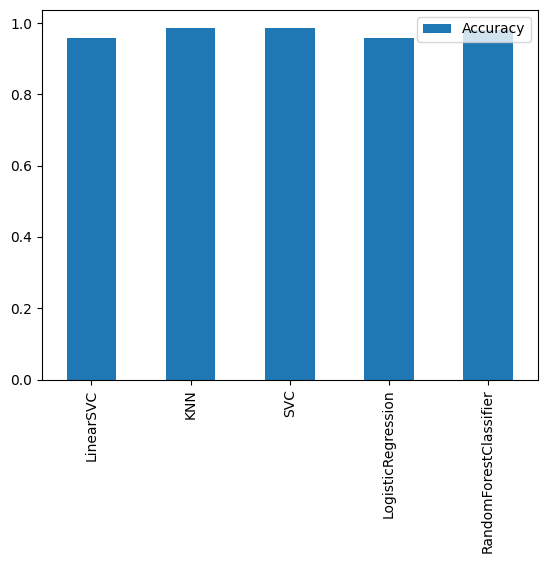

In [ ]:
# Create a pandas dataframe with the data as the values of the results dictionary,
# the index as the keys of the results dictionary and a single column called accuracy.
# Be sure to save the dataframe to a variable.
results_df = pd.DataFrame(results.values(),
                          results.keys(),
                          columns=["Accuracy"])

# Create a bar plot of the results dataframe using plot.bar()
results_df.plot.bar();

Использование `np.random.seed(42)` приводит к тому, что модель `LogisticRegression` работает лучше всего (по крайней мере, на моем компьютере).

Давайте настроим ее гиперпараметры и посмотрим, сможем ли мы улучшить ее.

### Настройка гиперпараметров
Помните, если вы когда-нибудь пытаетесь настроить гиперпараметры модели машинного обучения и не знаете, с чего начать, вы всегда можете поискать что-то вроде "настройка гиперпараметров НАЗВАНИЕ_МОДЕЛИ".

В случае с LogisticRegression вы можете наткнуться на статьи, такие как [Настройка гиперпараметров с использованием поиска по сетке от Криса Албона](https://chrisalbon.com/machine_learning/model_selection/hyperparameter_tuning_using_grid_search/).

В статье используется [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), но мы будем использовать [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

Различные гиперпараметры для поиска были настроены для вас в `log_reg_grid`, но не стесняйтесь изменять их.

In [ ]:
# Different LogisticRegression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["newton-cg"]}

Поскольку у нас есть набор гиперпараметров, мы можем импортировать `RandomizedSearchCV`, передать ему наш словарь гиперпараметров и позволить ему найти лучшую комбинацию.

In [ ]:
# Setup np random seed of 42
np.random.seed(42)

# Import RandomizedSearchCV from sklearn's model_selection module
from sklearn.model_selection import RandomizedSearchCV

# Setup an instance of RandomizedSearchCV with a LogisticRegression() estimator,
# our log_reg_grid as the param_distributions, a cv of 5 and n_iter of 5.
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=5,
                                verbose=True)

# Fit the instance of RandomizedSearchCV
rs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 5 candidates, totalling 25 fits


После завершения работы `RandomizedSearchCV` мы можем найти лучшие гиперпараметры, которые он нашел, используя атрибут `best_params_`.

In [ ]:
# Find the best parameters of the RandomizedSearchCV instance using the best_params_ attribute
rs_log_reg.best_params_

{'solver': 'newton-cg', 'C': np.float64(0.23357214690901212)}

In [ ]:
# Score the instance of RandomizedSearchCV using the test data
rs_log_reg.score(X_test, y_test)

0.9686832740213523

После настройки гиперпараметров улучшился ли показатель модели? Что еще вы могли бы попробовать, чтобы улучшить его? Есть ли другие методы настройки гиперпараметров, которые вы можете найти для `LogisticRegression`?

### Оценка модели классификатора
Мы попытались найти лучшие гиперпараметры для нашей модели с помощью `RandomizedSearchCV`, и до сих пор мы оценивали нашу модель только с помощью функции `score()`, которая возвращает точность.

Но когда дело доходит до классификации, вы, вероятно, захотите использовать еще несколько метрик оценки, включая:
* [**Матрица ошибок (Confusion matrix)**](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/) - Сравнивает прогнозируемые значения с истинными значениями в табличной форме. Если прогнозы на 100% верны, все значения в матрице будут от верхнего левого до нижнего правого (диагональная линия).
* [**Перекрестная проверка (Cross-validation)**](https://scikit-learn.org/stable/modules/cross_validation.html) - Разделяет ваш набор данных на несколько частей, обучает и тестирует вашу модель на каждой части и оценивает производительность как среднее.
* [**Точность (Precision)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score) - Доля истинно положительных результатов относительно общего количества выборок. Более высокая точность приводит к меньшему количеству ложных срабатываний.
* [**Полнота (Recall)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score) - Доля истинно положительных результатов относительно общего количества истинно положительных и ложно отрицательных результатов. Более высокая полнота приводит к меньшему количеству ложно отрицательных результатов.
* [**F1 score**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score) - Объединяет точность и полноту в одну метрику. 1 — лучшее, 0 — худшее.
* [**Отчет о классификации (Classification report)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) - В Sklearn есть встроенная функция `classification_report()`, которая возвращает некоторые основные метрики классификации, такие как точность, полнота и F-мера.
* [**ROC-кривая**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_score.html) - [Рабочая характеристика приемника](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) — это график зависимости истинно положительной скорости от ложноположительной скорости.
* [**Площадь под кривой (AUC)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) - Площадь под ROC-кривой. Идеальная модель достигает оценки 1,0.

Прежде чем мы перейдем к этому, мы создадим новый экземпляр нашей модели, используя лучшие гиперпараметры, найденные `RandomizedSearchCV`.


In [ ]:
# Instantiate a LogisticRegression classifier using the best hyperparameters from RandomizedSearchCV
clf = LogisticRegression(solver="newton-cg", C=0.23357214690901212)

# Fit the new instance of LogisticRegression with the best hyperparameters on the training data
clf.fit(X_train, y_train);

Теперь пора импортировать соответствующие методы Scikit-Learn для каждой из метрик оценки классификации, которые нам нужны.

In [ ]:
# Import confusion_matrix and classification_report from sklearn's metrics module
from sklearn.metrics import confusion_matrix, classification_report

# Import precision_score, recall_score and f1_score from sklearn's metrics module
from sklearn.metrics import precision_score, recall_score, f1_score

# Import plot_roc_curve from sklearn's metrics module
from sklearn.metrics import RocCurveDisplay

Метрики оценки очень часто сравнивают прогнозы модели с некоторыми истинными метками.

Давайте сделаем некоторые прогнозы на тестовых данных с помощью нашей последней модели и сохраним их в `y_preds`.


In [ ]:
# Make predictions on test data and save them
y_preds = clf.predict(X_test)

Теперь можно использовать прогнозы, которые сделала наша модель, чтобы оценить ее качество(beyond accuracy).

In [ ]:
# Create a confusion matrix using the confusion_matrix function
confusion_matrix(y_test, y_preds)

array([[136,   0,   0,   0,   0,   0,   0,   0,   1,   0],
       [  0, 139,   0,   0,   2,   0,   0,   0,   3,   0],
       [  0,   0, 126,   0,   0,   1,   0,   0,   0,   0],
       [  0,   0,   1, 134,   0,   3,   0,   0,   2,   1],
       [  0,   0,   0,   0, 143,   0,   2,   0,   2,   1],
       [  0,   1,   0,   1,   0, 121,   0,   0,   0,   4],
       [  1,   2,   0,   0,   1,   1, 139,   0,   0,   0],
       [  0,   0,   1,   1,   0,   0,   0, 158,   0,   0],
       [  0,   1,   1,   0,   1,   1,   0,   0, 124,   0],
       [  0,   1,   0,   2,   0,   1,   0,   2,   2, 141]])

**Задача:** Встроенная функция `confusion_matrix` в Scikit-Learn выдает что-то не слишком наглядное, как вы могли бы сделать вашу матрицу ошибок более визуальной?

Вы можете поискать что-то вроде "как построить матрицу ошибок". Примечание: может быть более одного способа сделать это.


In [ ]:
import sys
!pip install seaborn

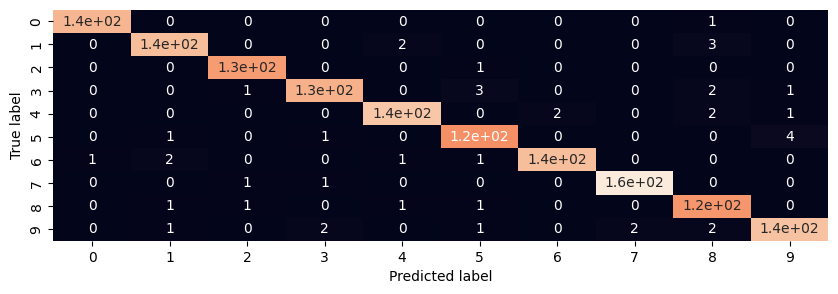

In [ ]:
# Create a more visual confusion matrix
# Import seaborn for improving visualisaztion of confusion matrix
import seaborn as sns

# Make confusion matrix more visual
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(10, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                    annot=True, # Annotate the boxes
                    cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plot_conf_mat(y_test, y_preds)

Теперь необходимо сформировать отчет о классификации.

In [ ]:
# Create a classification report using the classification_report function
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       137
           1       0.97      0.97      0.97       144
           2       0.98      0.99      0.98       127
           3       0.97      0.95      0.96       141
           4       0.97      0.97      0.97       148
           5       0.95      0.95      0.95       127
           6       0.99      0.97      0.98       144
           7       0.99      0.99      0.99       160
           8       0.93      0.97      0.95       128
           9       0.96      0.95      0.95       149

    accuracy                           0.97      1405
   macro avg       0.97      0.97      0.97      1405
weighted avg       0.97      0.97      0.97      1405



**Задача:** Запишите, что означает каждый из столбцов в этом отчете о классификации.

* **Precision** - Указывает долю положительных идентификаций (модель предсказала класс 1), которые были фактически правильными. Модель, которая не дает ложных срабатываний, имеет точность 1,0.
* **Recall** - Указывает долю фактических положительных результатов, которые были правильно классифицированы. Модель, которая не дает ложноотрицательных результатов, имеет полноту 1,0.
* **F1 score** - Комбинация точности и полноты. Идеальная модель достигает оценки F1 1,0.
* **Support** - Количество образцов, для которых была вычислена каждая метрика.
* **Accuracy** - Точность модели в десятичной форме. Идеальная точность равна 1,0.
* **Macro avg** - Сокращение от macro average, среднее значение точности, полноты и F1 score между классами. Macro avg не учитывает дисбаланс классов, поэтому если у вас есть дисбаланс классов, обратите внимание на эту метрику.
* **Weighted avg** - Сокращение от weighted average, взвешенное среднее значение точности, полноты и F1 score между классами. Weighted означает, что каждая метрика вычисляется с учетом того, сколько образцов находится в каждом классе. Эта метрика будет благоприятствовать majority class (например, будет давать высокое значение, когда один класс превосходит другой из-за большего количества образцов).

Отчет о классификации дает нам диапазон значений для точности, полноты и F1 score, пора найти эти метрики с помощью функций Scikit-Learn.


In [ ]:
# Find the precision score of the model using precision_score()
precision_score(y_test, y_preds, average='weighted')

0.9689043466699598

In [ ]:
# Find the recall score
recall_score(y_test, y_preds, average='weighted')

0.9686832740213523

In [ ]:
# Find the F1 score
f1_score(y_test, y_preds, average='weighted')

0.9687137986582172

Матрица ошибок: готово.
Отчет о классификации: готово.
ROC-кривая (рабочая характеристика приемника) и оценка AUC (площадь под кривой): не готово.

Давайте исправим это.

Если вы не знакомы с тем, что такое ROC-кривая, это ваша первая задача — прочитать о том, что это такое.

В двух словах, [ROC-кривая](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) — это график зависимости истинно положительной скорости от ложноположительной скорости.

А оценка AUC — это площадь под ROC-кривой.

Scikit-Learn предоставляет удобную функцию для создания обоих этих графиков, называемую [`plot_roc_curve()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_roc_curve.html).



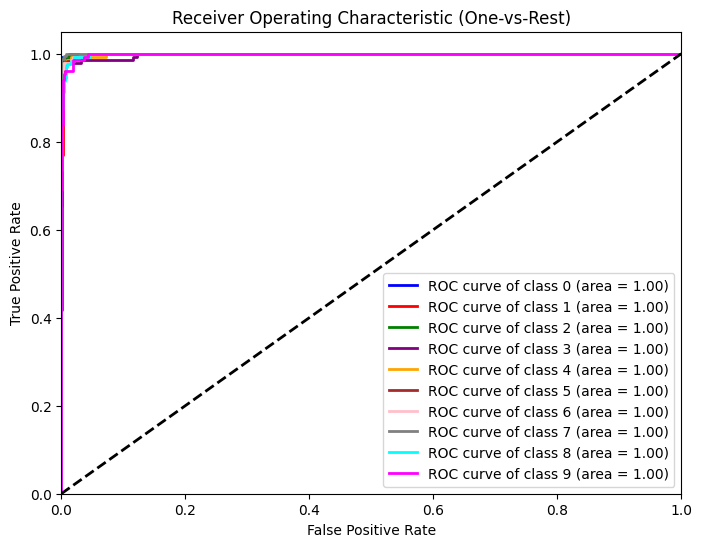

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# 1. Преобразуйте целевую переменную в бинарный формат (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# 2. Получите вероятности предсказаний для каждого класса
y_score = clf.predict_proba(X_test)

# 3. Постройте ROC-кривую для каждого класса
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Постройте графики ROC-кривых
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta'] # Достаточно цветов для 10 классов

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()


 Мы вышли далеко за пределы точности с множеством дополнительных метрик оценки классификации.


Важно отметить, что все эти метрики были рассчитаны с использованием одного обучающего набора и одного тестового набора. Хотя это нормально, более надежный способ — вычислить их с помощью [перекрестной проверки](https://scikit-learn.org/stable/modules/cross_validation.html).

Мы можем вычислить различные метрики оценки с помощью перекрестной проверки, используя функцию Scikit-Learn [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) вместе с параметром `scoring`.


In [ ]:
# Import cross_val_score from sklearn's model_selection module
from sklearn.model_selection import cross_val_score

In [ ]:
if isinstance(y, (pd.Series, pd.DataFrame)):
    y = y.values

# Ensure y is 1D using .ravel()
scores = cross_val_score(clf, X, y.ravel(), scoring="accuracy", cv=5)


In [ ]:
# Convert y to a NumPy array if it's a DataFrame/Series
if isinstance(y, (pd.Series, pd.DataFrame)):
    y = y.values

# Ensure y is 1D using .ravel()
scores = cross_val_score(clf, X, y.ravel(), scoring="accuracy", cv=5)

scores

array([0.96975089, 0.96174377, 0.97241993, 0.95996441, 0.96174377])

В примерах перекрестно проверенная точность находится путем взятия среднего значения массива, возвращаемого `cross_val_score()`.

In [ ]:
cross_val_precision = np.mean(cross_val_score(clf,
                                              X,
                                              y.ravel(),
                                              scoring="precision_macro",
                                              cv=5))

cross_val_precision

np.float64(0.965725194195637)

In [ ]:
# Find the cross-validated recall
cross_val_recall = np.mean(cross_val_score(clf,
                                           X,
                                           y.ravel(),
                                           scoring="recall_macro",
                                          cv=5))

cross_val_recall

np.float64(0.9651795431495973)

In [ ]:
# Find the cross-validated F1 score
cross_val_f1 = np.mean(cross_val_score(clf,
                                       X,
                                       y.ravel(),
                                       scoring="f1_macro",
                                       cv=5))

cross_val_f1

np.float64(0.9651393745711921)

### Экспорт и импорт обученной модели
После того как вы обучили модель, вы можете захотеть экспортировать ее и сохранить в файл, чтобы поделиться ею или использовать в другом месте.

Один из методов экспорта и импорта моделей — использование библиотеки joblib.

В Scikit-Learn экспорт и импорт обученной модели известен как [сохранение модели](https://scikit-learn.org/stable/modules/model_persistence.html).


In [ ]:
# Import the dump and load functions from the joblib library
from joblib import dump, load

In [ ]:
# Use the dump function to export the trained model to file
dump(clf, "trained-classifier.joblib")

['trained-classifier.joblib']

In [ ]:
# Use the load function to import the trained model you just exported
# Save it to a different variable name to the origial trained model
loaded_clf = load("trained-classifier.joblib")

# Evaluate the loaded trained model on the test data
loaded_clf.score(X_test, y_test)

0.9686832740213523

In [ ]:
clf.score(X_test, y_test)

0.9686832740213523

Что вы заметили в результатах загруженной обученной модели по сравнению с исходной (до экспорта) моделью?

Выглядят одинаково!

## Практика регрессии в Scikit-Learn
В течение следующих нескольких упражнений мы будем работать над проблемой регрессии, другими словами, используя некоторые данные для прогнозирования числа.

Наш набор данных — это [таблица продаж автомобилей](https://docs.google.com/spreadsheets/d/1LPEIWJdSSJYrfn-P3UQDIXbEn5gg-o6I7ExLrWTTBWs/edit?usp=sharing), содержащая различные характеристики автомобилей, а также цену продажи.

Мы будем использовать встроенные модели регрессии машинного обучения Scikit-Learn, чтобы попытаться изучить закономерности в характеристиках автомобилей и их ценах на определенной группе набора данных, прежде чем пытаться предсказать цену продажи группы автомобилей, которую модель никогда раньше не видела.

Для начала мы [импортируем данные из GitHub](https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended-missing-data.csv) в DataFrame pandas, изучим некоторые детали об этом и попытаемся как можно скорее построить модель.


In [39]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets







In [40]:
# Combine features and target into a single DataFrame for easier analysis if needed
df = pd.concat([X, y], axis=1)  # axis=1 concatenates along columns

# Get information about DataFrame (combined DataFrame in this case)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


Глядя на вывод `info()`,
* Сколько всего строк?
* Какие типы данных в каждом столбце?
* Сколько пропущенных значений в каждом столбце?


In [41]:
# Find number of missing values in each column (of combined DataFrame)
print(df.isna().sum())


# If you want to check for missing values in features (X) and targets (y) separately:
print("Missing values in features (X):")
print(X.isna().sum())

print("\nMissing values in target (y):")
print(y.isna().sum())

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64
Missing values in features (X):
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Missing values in target (y):
mpg    0
dtype: int64


In [42]:
# Find the datatypes of each column
print(X.dtypes, y.dtypes)

displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
dtype: object mpg    float64
dtype: object


Зная эту информацию, что произойдет, если мы попробуем смоделировать наши данные "как есть"?



In [31]:
from sklearn.ensemble import RandomForestRegressor

# Separate features (X) and target (y)
auto_mpg_X = df["mpg"]  # Correctly drop from the combined DataFrame
auto_mpg_y = df["mpg"]

rf_regressor = RandomForestRegressor().fit(auto_mpg_X, auto_mpg_y)



ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

Как мы видим, ячейка выше выдает ошибку, потому что наши данные содержат нечисловые значения, а также пропущенные данные.

Чтобы устранить часть пропущенных данных, мы удалим строки, в которых отсутствуют целевые значения (все строки с пропущенными значениями в столбце Price).

In [43]:
# Drop rows with missing values in the "displacement" column
df.dropna(subset=["mpg"], inplace=True) #удаляет если пропущено в displacement

# Separate features (X) and target (y)
auto_mpg_X = df.drop("mpg", axis=1)
auto_mpg_y = df["mpg"]

rf_regressor = RandomForestRegressor().fit(auto_mpg_X, auto_mpg_y)

### Создание конвейера (pipeline)

Поскольку наши данные `car_sales` содержат пропущенные числовые значения и представлены не только числами, нам нужно устранить эти проблемы, прежде чем мы сможем обучить на них модель машинного обучения.

Существуют способы сделать это с помощью pandas, но так как мы практикуем работу с Scikit-Learn, мы посмотрим, как это можно сделать с помощью класса [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

Поскольку мы изменяем столбцы в нашем DataFrame (заполняем пропущенные значения, преобразуем нечисловые данные в числа), нам также понадобятся классы [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) и [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

Наконец, поскольку нам нужно разделить наши данные на обучающий и тестовый наборы, мы также импортируем `train_test_split`.

In [44]:
# Import Pipeline from sklearn's pipeline module
from sklearn.pipeline import Pipeline

# Import ColumnTransformer from sklearn's compose module
from sklearn.compose import ColumnTransformer

# Import SimpleImputer from sklearn's impute module
from sklearn.impute import SimpleImputer

# Import OneHotEncoder from sklearn's preprocessing module
from sklearn.preprocessing import OneHotEncoder

# Import train_test_split from sklearn's model_selection module
from sklearn.model_selection import train_test_split

Теперь у нас есть необходимые инструменты для создания конвейера предобработки (`Pipeline`), который заполнит пропущенные значения и преобразует все нечисловые данные в числа.

Давайте начнём с категориальных признаков.

In [53]:
# Define different categorical features
categorical_features = ["cylinders", "model_year", "origin"]

# Create categorical transformer Pipeline
categorical_transformer = Pipeline(steps=[
    # Set SimpleImputer strategy to "median"
    ("imputer", SimpleImputer(strategy="median")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

Было бы правильно также обращаться с Doors как с категориальным признаком, однако, поскольку мы знаем, что подавляющее большинство автомобилей имеют 4 двери, мы заполним пропущенные значения в Doors числом 4.

In [ ]:
# Пропускаем

Теперь перейдем к числовым признакам. В данном случае единственным числовым признаком является столбец `Odometer (KM)` (Пробег, км). Давайте заполним его пропущенные значения медианой.


In [54]:
# Define numeric features (only the Odometer (KM) column)
numeric_features = ["displacement", "horsepower", "weight", "acceleration"]

# Crearte numeric transformer Pipeline
numeric_transformer = Pipeline(steps=[
    # Set SimpleImputer strategy to fill missing values with the "Median"
    ("imputer", SimpleImputer(strategy="median"))])

Время объединить все наши отдельные конвейеры преобразований (`Pipeline`) в один экземпляр `ColumnTransformer`.

In [55]:
# Setup preprocessing steps (fill missing values, then convert to numbers)
preprocessor = ColumnTransformer(
    transformers=[
        # Use the categorical_transformer to transform the categorical_features
        ("cat", categorical_transformer, categorical_features),
        # Use the numeric_transformer to transform the numeric_features
        ("num", numeric_transformer, numeric_features)])

Теперь наш `preprocessor` готов, пора импортировать несколько регрессионных моделей для тестирования.

Сравнивая наши данные с [картой алгоритмов машинного обучения Scikit-Learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html), мы видим, что есть несколько различных регрессионных моделей, которые мы можем попробовать:

* [RidgeRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) (Ридж-регрессия)
* [SVR(kernel="linear")](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) - Support Vector Regressor (метод опорных векторов для регрессии) с линейным ядром
* [SVR(kernel="rbf")](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) - Support Vector Regressor с радиально-базисным ядром (RBF)
* [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) - регрессионная версия алгоритма RandomForest

In [48]:
# Import Ridge from sklearn's linear_model module
from sklearn.linear_model import Ridge

# Import SVR from sklearn's svm module
from sklearn.svm import SVR

# Import RandomForestRegressor from sklearn's ensemble module
from sklearn.ensemble import RandomForestRegressor

И снова, благодаря архитектуре библиотеки Scikit-Learn, мы можем использовать очень похожий код для каждой из этих моделей.

Чтобы протестировать их все, мы создадим словарь регрессионных моделей и пустой словарь для результатов работы моделей.

In [56]:
# Create dictionary of model instances, there should be 4 total key, value pairs
# in the form {"model_name": model_instance}.
# Don't forget there's two versions of SVR, one with a "linear" kernel and the
# other with kernel set to "rbf".
regression_models = {"Ridge": Ridge(),
                     "SVR_linear": SVR(kernel="linear"),
                     "SVR_rbf": SVR(kernel="rbf"),
                     "RandomForestRegressor": RandomForestRegressor()}

# Create an empty dictionary for the regression results
regression_results = {}

Наш словарь регрессионных моделей подготовлен, а также создан пустой словарь для сохранения результатов. Пришло время разделить данные на `X` (признаки) и `y` (целевую переменную), а также на обучающую и тестовую выборки.

В нашей задаче с продажей автомобилей мы пытаемся использовать различные характеристики автомобиля (`X`) для прогнозирования его продажной цены (`y`).

In [57]:
auto_mpg = pd.concat([X, y], axis=1)

# Now you can correctly drop and access the target
auto_mpg_X = auto_mpg.drop("mpg", axis=1)
auto_mpg_y = auto_mpg["mpg"]




In [58]:
auto_mpg_X_train, auto_mpg_X_test, auto_mpg_y_train, auto_mpg_y_test = train_test_split(auto_mpg_X,
                                                                    auto_mpg_y,
                                                                    test_size=0.2,
                                                                    random_state=42)

# Check the shapes of the training and test datasets
auto_mpg_X_train.shape, auto_mpg_X_test.shape, auto_mpg_y_train.shape, auto_mpg_y_test.shape

((318, 7), (80, 7), (318,), (80,))

*   Сколько строк в каждом наборе?
*   Сколько столбцов в каждом наборе?

Хорошо, наши данные разделены на обучающую и тестовую выборки. Пришло время создать небольшой цикл, который будет:
1.  Перебирать наш словарь `regression_models`
2.  Создавать `Pipeline`, содержащий наш `preprocessor` и одну из моделей из словаря
3.  Обучать `Pipeline` на обучающих данных по продаже автомобилей
4.  Оценивать целевую модель на тестовых данных по продаже автомобилей и добавлять результаты в наш словарь `regression_results`

In [59]:
# Loop through the items in the regression_models dictionary
for model_name, model in regression_models.items():

    # Create a model Pipeline with a preprocessor step and model step
    model_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                      ("model", model)])

    # Fit the model Pipeline to the car sales training data
    print(f"Fitting {model_name}...")
    model_pipeline.fit(auto_mpg_X_train, auto_mpg_y_train)

    # Score the model Pipeline on the test data appending the model_name to the
    # results dictionary
    print(f"Scoring {model_name}...")
    regression_results[model_name] = model_pipeline.score(auto_mpg_X_test,
                                                          auto_mpg_y_test)

Fitting Ridge...
Scoring Ridge...
Fitting SVR_linear...
Scoring SVR_linear...
Fitting SVR_rbf...
Scoring SVR_rbf...
Fitting RandomForestRegressor...
Scoring RandomForestRegressor...


Наши регрессионные модели обучены, давайте посмотрим, как они справились.

In [60]:
# Check the results of each regression model by printing the regression_results
# dictionary
regression_results

{'Ridge': 0.8063706073973985,
 'SVR_linear': 0.5052721992942918,
 'SVR_rbf': 0.7433147370803168,
 'RandomForestRegressor': 0.8473368545041629}

*   **Какая модель показала наилучший результат?**
*   **Как можно улучшить её результаты?**
*   **Какую метрику возвращает метод `score()` регрессионной модели по умолчанию?**

Поскольку мы обучили несколько моделей, но сравнили их только с помощью метрики по умолчанию, содержащейся в методе `score()` (R^2 score или коэффициент детерминации), давайте возьмем модель `RidgeRegression` и оценим её с помощью нескольких других [метрик регрессии](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics).

А именно, найдем:
1.  **R^2 (произносится как R-квадрат) или коэффициент детерминации** - Сравнивает прогнозы вашей модели со средним значением целевой переменной. Значения могут варьироваться от отрицательной бесконечности (очень плохая модель) до 1. Например, если ваша модель предсказывает только среднее значение целей, её R^2 будет равен 0. А если ваша модель идеально предсказывает ряд чисел, её R^2 будет равен 1.
2.  **Средняя абсолютная ошибка (MAE)** - Среднее значение абсолютных разниц между прогнозами и фактическими значениями. Дает представление о том, насколько ошибочными были ваши прогнозы.
3.  **Средняя квадратичная ошибка (MSE)** - Среднее значение квадратов разниц между прогнозами и фактическими значениями. Возведение в квадрат устраняет отрицательные ошибки. Это также усиливает влияние выбросов (примеров с большими ошибками).

В Scikit-Learn есть встроенные классы, которые помогут нам в этом, а именно:
*   [`mean_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
*   [`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
*   [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [61]:
# Import mean_absolute_error from sklearn's metrics module
from sklearn.metrics import mean_absolute_error

# Import mean_squared_error from sklearn's metrics module
from sklearn.metrics import mean_squared_error

# Import r2_score from sklearn's metrics module
from sklearn.metrics import r2_score

Все метрики оценки, которые нас интересуют, сравнивают прогнозы модели с истинными значениями (ground truth). Зная это, нам нужно сделать несколько прогнозов.

Давайте создадим `Pipeline` с `preprocessor` и моделью `Ridge()`, обучим его на обучающих данных по продаже автомобилей, а затем сделаем прогнозы на тестовых данных.

In [62]:
# Create RidgeRegression Pipeline with preprocessor as the "preprocessor" and
# Ridge() as the "model".
ridge_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                 ("model", Ridge())])

# Fit the RidgeRegression Pipeline to the car sales training data
ridge_pipeline.fit(auto_mpg_X_train, auto_mpg_y_train)

# Make predictions on the car sales test data using the RidgeRegression Pipeline
auto_mpg_y_preds = ridge_pipeline.predict(auto_mpg_X_test)

# View the first 50 predictions
auto_mpg_y_preds[:50]

array([34.02670438, 28.23966384, 20.47105547, 16.24702346, 13.85675516,
       29.5717426 , 26.43432907,  7.97672422, 19.30679418, 19.41435143,
       14.26908661, 34.76138491, 28.73173341, 16.12440571, 26.56942992,
       10.88077852, 27.72408179, 17.33482234, 14.6101092 , 34.64497237,
       28.12568159, 19.41551594, 21.00263412, 27.69991312, 19.79019512,
       34.22919378, 26.17985121, 25.58463838, 16.56126687, 11.1198643 ,
       27.29694095, 32.88835908, 21.16626261, 28.5035457 , 36.01389872,
        7.62141621, 17.54823879, 19.3238762 , 13.77040582, 28.23120755,
       19.26751049, 32.18027731, 23.06667607,  8.35268133, 27.54867381,
       32.53775718, 29.21244917, 23.57927082, 26.74786283, 28.93327418])

 Теперь, когда у нас есть прогнозы, пришло время их оценить. Мы найдем:
*   Среднюю квадратичную ошибку (MSE)
*   Среднюю абсолютную ошибку (MAE)
*   R^2 score (коэффициент детерминации) нашей модели.

In [63]:
# EXAMPLE: Find the MSE by comparing the car sales test labels to the car sales predictions
mse = mean_squared_error(auto_mpg_y_test, auto_mpg_y_preds)
# Return the MSE
mse

10.410763845714442

In [64]:
# Find the MAE by comparing the car sales test labels to the car sales predictions
mae = mean_absolute_error(auto_mpg_y_test, auto_mpg_y_preds)
# Return the MAE
mae

2.554780026408821

In [65]:
# Find the R^2 score by comparing the car sales test labels to the car sales predictions
r2 = r2_score(auto_mpg_y_test, auto_mpg_y_preds)
# Return the R^2 score
r2

0.8063706073973985

Нашей модели, потенциально, может помочь настройка гиперпараметров (это было бы отличным улучшением). И, вероятно, нам не помешало бы найти больше данных для нашей задачи — 1000 строк кажется недостаточным.

Как вы экспортировали бы обученную регрессионную модель?

In [68]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import randint, uniform
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg_repo = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg_repo.data.features  # Features
y = auto_mpg_repo.data.targets['mpg']  # Target (select only the target)


# Get the numeric and categorical column names
numeric_features = X.select_dtypes(include=['number']).columns.tolist()  # Corrected
categorical_features = ['cylinders', 'origin', 'model_year']

# Create the preprocessors for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing with the mean
    ('scaler', StandardScaler())  # Scale the features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing with the most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode
])

# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'  # Keep other columns not specified (like 'horsepower' if needed)
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = RandomForestRegressor(random_state=42)

# Create a pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', model)])

# Define the hyperparameter distributions to search
param_distributions = {
    'rf__n_estimators': randint(100, 1000),        # Integer values
    'rf__max_depth': randint(5, 20),            # Integer values
    'rf__min_samples_split': randint(2, 20),    # Integer values
    'rf__min_samples_leaf': randint(1, 10),     # Integer values
    'rf__max_features': ['sqrt', 'log2', None],  # Categorical or None
    'rf__bootstrap': [True, False]            # Boolean
}

# Perform randomized search with cross-validation
random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=10, cv=5, scoring='r2', random_state=42) # n_iter - количество итераций
random_search.fit(X_train, y_train)

# Get the best model
best_model = random_search.best_estimator_

# Print best parameters and score
print("Best parameters:", random_search.best_params_)
print("Best R2 score:", random_search.best_score_)

# Evaluate on the test set
test_score = best_model.score(X_test, y_test)
print("Test R2 score:", test_score)



Best parameters: {'rf__bootstrap': False, 'rf__max_depth': 18, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 559}
Best R2 score: 0.8558916649726488
Test R2 score: 0.9054363135455546


In [70]:
# Import the dump and load functions from the joblib library
from joblib import dump, load
# Use the dump function to export the trained model to file
dump(best_model, "regression_model.joblib")

['regression_model.joblib']

## Дополнительные задания (Extensions)

 То, что вы дошли до этого момента, означает, что вы решили задачу классификации и задачу регрессии, используя (в основном) только Scikit-Learn (что непросто!).

Для дополнительных упражнений ознакомьтесь с [документацией по началу работы](https://scikit-learn.org/stable/getting_started.html) Scikit-Learn. Хорошей практикой будет прочитать её и добавить заинтересовавшие вас части в конец этого блокнота.

И, наконец, как всегда, помните: лучший способ изучить что-то новое — попробовать это. И пробовать неуклонно. Если вы не уверены, как что-то сделать, никогда не бойтесь задать вопрос или поискать что-то вроде: «как настроить гиперпараметры модели ридж-регрессии в scikit-learn».